In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hashlib as hl

In [2]:
data = pd.read_csv("athlete_events.csv")
data["Name"] = data["Name"].apply(lambda x: hl.sha256(str(x).encode("utf-8")).hexdigest())
data = data[data["Team"] == "France"].sort_values("Year")
data.dropna(subset=["Year", "Medal"], inplace=True)

<Axes: xlabel='Year'>

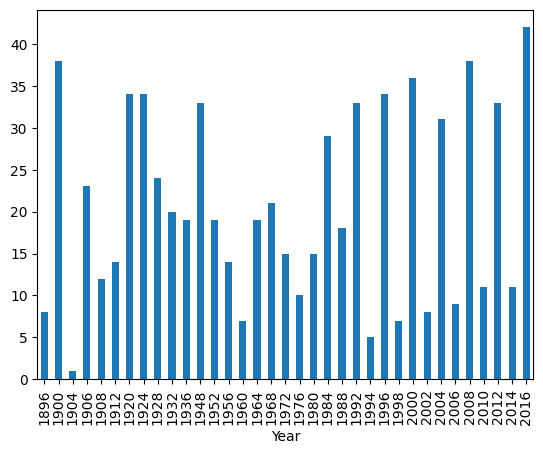

In [3]:
#medaljer dom vunnit sammanlagt varje år
medaljer = data.drop_duplicates(subset=["Year", "Event"])
medaljer.groupby("Year")["Event"].count().plot(kind="bar")

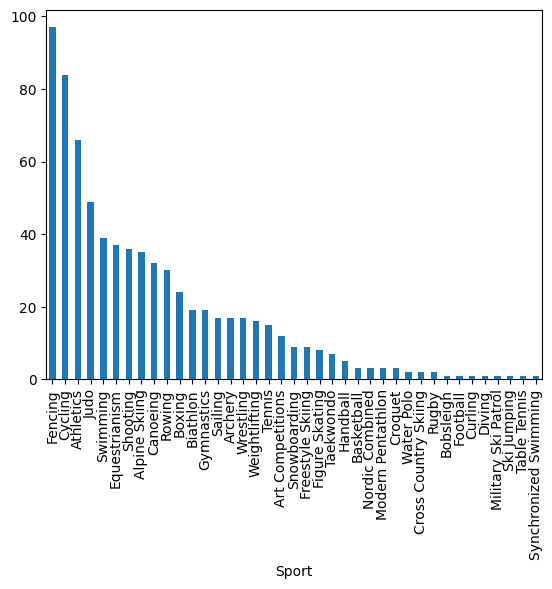

In [4]:
# hur många vinster dom har i alla sporter
sporter = data.drop_duplicates(subset=["Year", "Event"]).sort_values("Sport").value_counts("Sport").plot(kind="bar")

In [5]:
# ålderskillnad på dom olika sporterna
age_diff = data.groupby("Sport")["Age"]
age_diff

<Axes: ylabel='Frequency'>

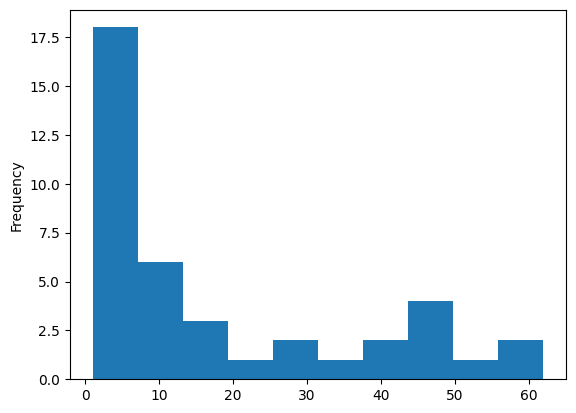

In [15]:
age = data.sort_index()
age.dropna(subset=["Year", "Medal"], inplace=True)
age.drop_duplicates(subset=["Year", "Event"]).sort_values("Age").value_counts("Age").plot(kind="hist")
